In [137]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [138]:
df = pd.read_csv('customer_segmentation.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [139]:
df.shape

(2240, 29)

In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [141]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [142]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [143]:
df.columns.to_list()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

In [144]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [145]:
df.isnull().sum().sum()

np.int64(24)

In [146]:
df.duplicated().sum()

np.int64(0)

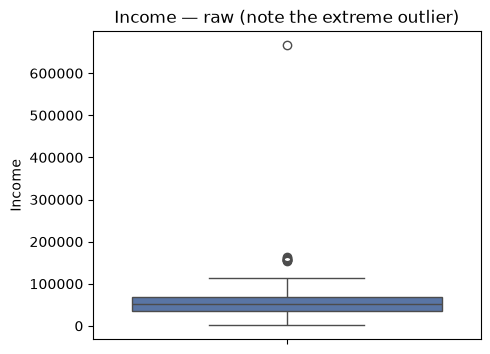

In [147]:
# checking outliera 
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(y=df["Income"], ax=ax, color="#4C72B0")
ax.set_title("Income — raw (note the extreme outlier)")
plt.show()

In [148]:
## Remove implausible records
df = df.drop_duplicates()

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
REFERENCE_DATE = df["Dt_Customer"].max()
REFERENCE_YEAR = REFERENCE_DATE.year
print("Reference date used for Age / tenure calculations:", REFERENCE_DATE.date())

# Impute missing income with the median
df["Income"] = df["Income"].fillna(df["Income"].median())

before = len(df)
df["Age_tmp"] = REFERENCE_YEAR - df["Year_Birth"]
df = df[(df["Age_tmp"] <= 90) & (df["Income"] <= 600000)].drop(columns="Age_tmp")
print(f"Dropped {before - len(df)} outlier/implausible rows -> {len(df)} rows remain.")

df = df.drop(columns=["Z_CostContact", "Z_Revenue"])


Reference date used for Age / tenure calculations: 2014-06-29
Dropped 4 outlier/implausible rows -> 2236 rows remain.


In [149]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


In [150]:
df['Income'].value_counts()

Income
51381.5    24
7500.0     12
35860.0     4
37760.0     3
34176.0     3
           ..
26816.0     1
61223.0     1
56981.0     1
69245.0     1
52869.0     1
Name: count, Length: 1971, dtype: int64

In [151]:
df['Response'].value_counts()

Response
0    1902
1     334
Name: count, dtype: int64

In [152]:
# Dropping unused columns
df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"],inplace=True)

In [153]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='str')

In [154]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    578
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [155]:
df['Education'].value_counts()

Education
Graduation    1126
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

In [156]:
#Merging the colums into All parts
df['Age'] = REFERENCE_YEAR - df['Year_Birth']
df["Customer_Tenure_Days"] = (REFERENCE_DATE- df["Dt_Customer"]).dt.days

spend_col = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds',]
df['total_spend'] = df[spend_col].sum(axis = 1)

purchase_col = ['NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases']
df['total_purchase'] = df[purchase_col].sum(axis = 1)

campaigns_col = ['AcceptedCmp3', 'AcceptedCmp4','AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2',]
df['total_campaigns'] = df[campaigns_col].sum(axis = 1)

df['children'] = df['Kidhome'] + df['Teenhome'] 

df['living_with'] = df['Marital_Status'].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone":  "Alone",
    "Absurd" :"Alone",
    "YOLO" : "Alone",
})

df['family_size'] = df['living_with'].map({"Partner" : 2 , "Alone" : 1}) + df['children']

df['Education_level'] = df['Education'].replace({
    'Basic' : "Undergraduate",
    '2n Cycle' : 'Graduate',
    "Graduation" : 'Graduate',
    'Master' : 'Postgraduate',
    'PhD' : 'Postgraduate'
})

print('After merging all Columns Shapes : ' , df.shape)
df[['Age' , 'Customer_Tenure_Days' , 'total_spend' , 'total_purchase' , 'total_campaigns' ,  'children' , 'living_with' , 'family_size' ,'Education_level']].head()

After merging all Columns Shapes :  (2236, 36)


,Age,Customer_Tenure_Days,total_spend,total_purchase,total_campaigns,children,living_with,family_size,Education_level
0,57,663,1617,25,0,0,Alone,1,Graduate
1,60,113,27,6,0,2,Alone,3,Graduate
2,49,312,776,21,0,0,Partner,2,Graduate
3,30,139,53,8,0,1,Partner,3,Graduate
4,33,161,422,19,0,1,Partner,3,Postgraduate


## EDA

In [157]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days',
       'total_spend', 'total_purchase', 'total_campaigns', 'children',
       'living_with', 'family_size', 'Education_level'],
      dtype='str')

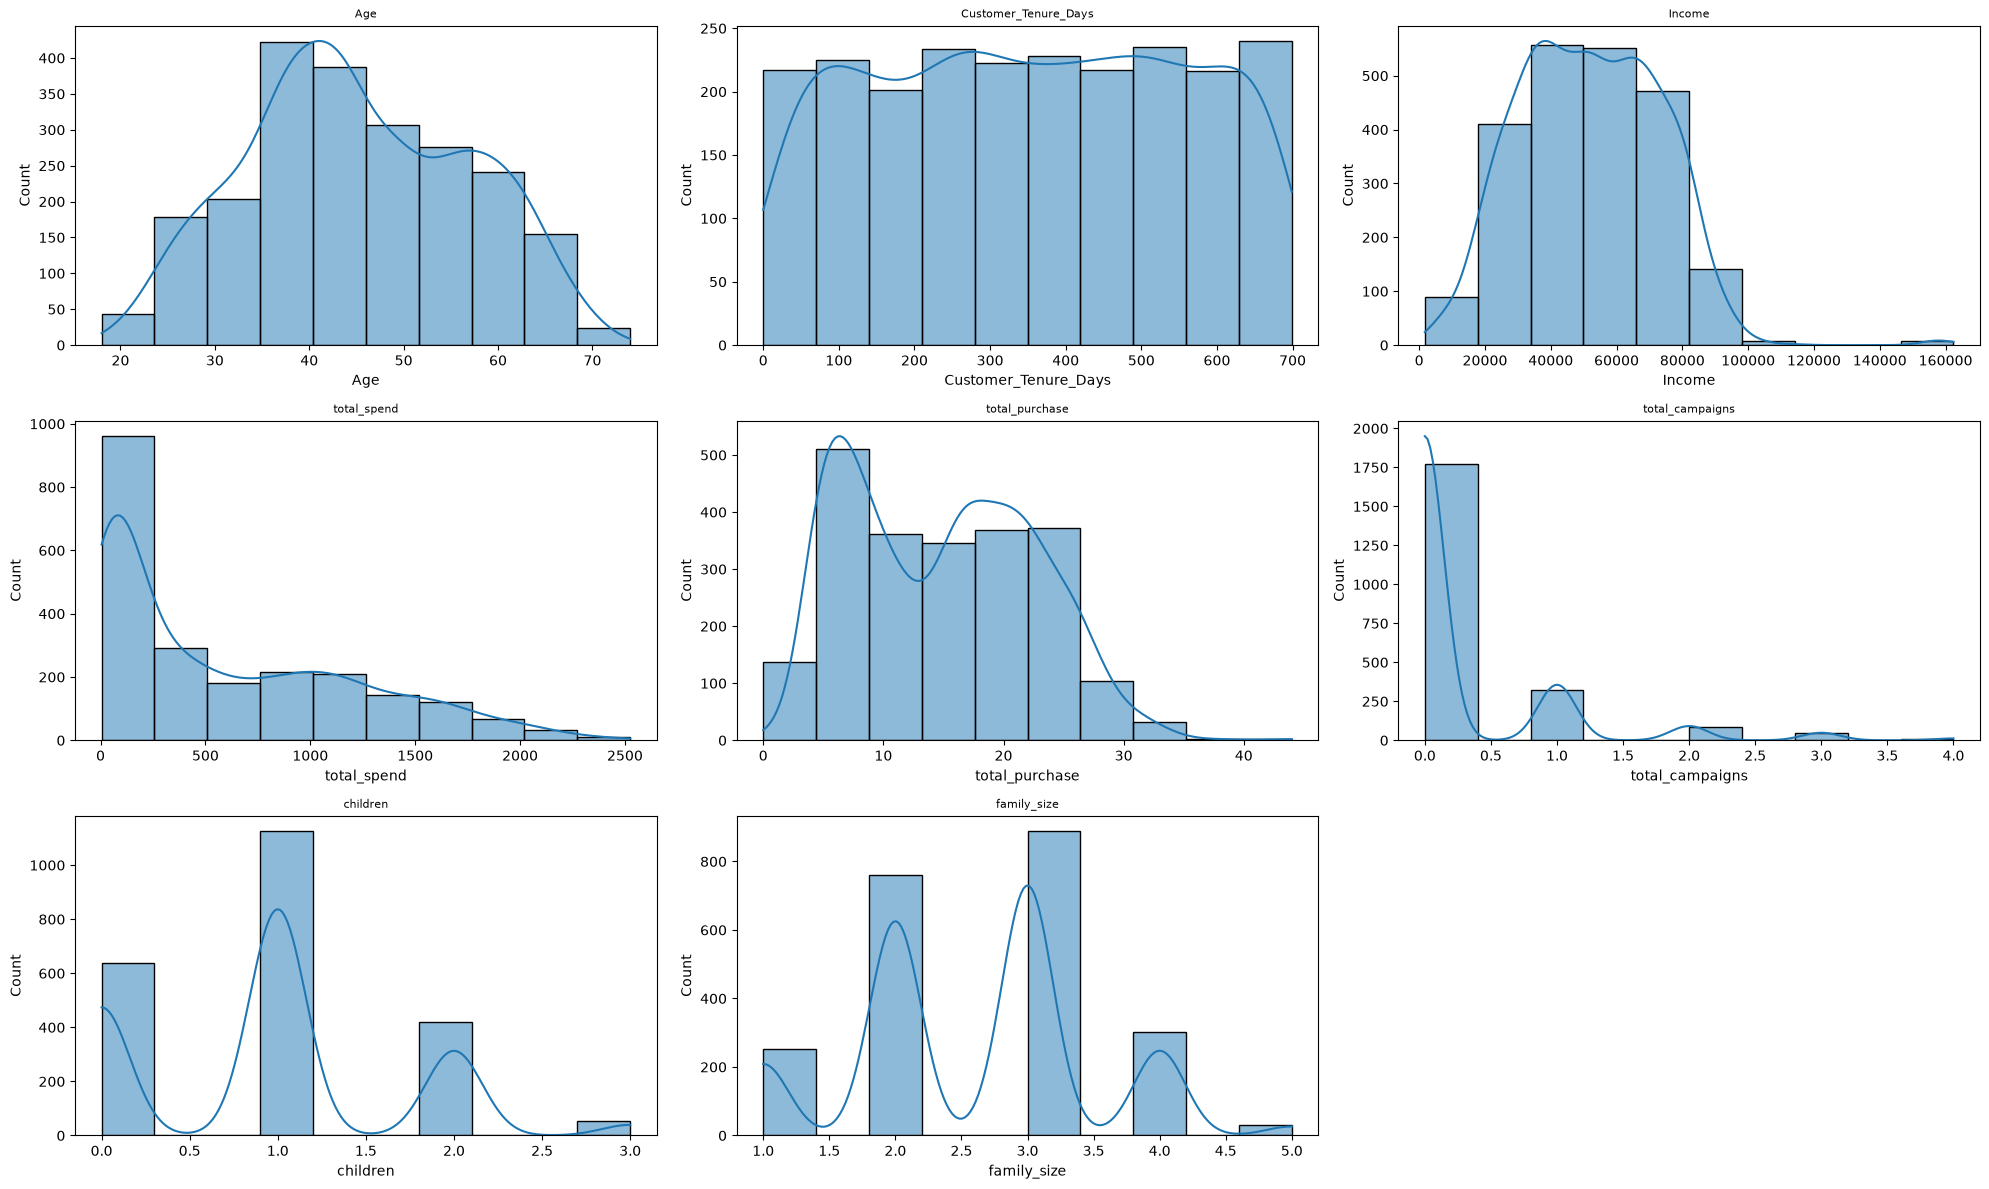

In [158]:
#sub plot of nummrical columns
plt.figure(figsize=(20 , 12))
def plotting(var , col):
    plt.subplot(3,3 ,col),
    sns.histplot(data = df , x = var , bins = 10 , kde = True)
    plt.title(var , fontsize = 8)

plotting("Age", 1)
plotting("Customer_Tenure_Days", 2)
plotting("Income", 3)
plotting("total_spend", 4)
plotting("total_purchase", 5)
plotting("total_campaigns", 6)
plotting("children", 7)
plotting("family_size", 8)

plt.tight_layout()
plt.show()

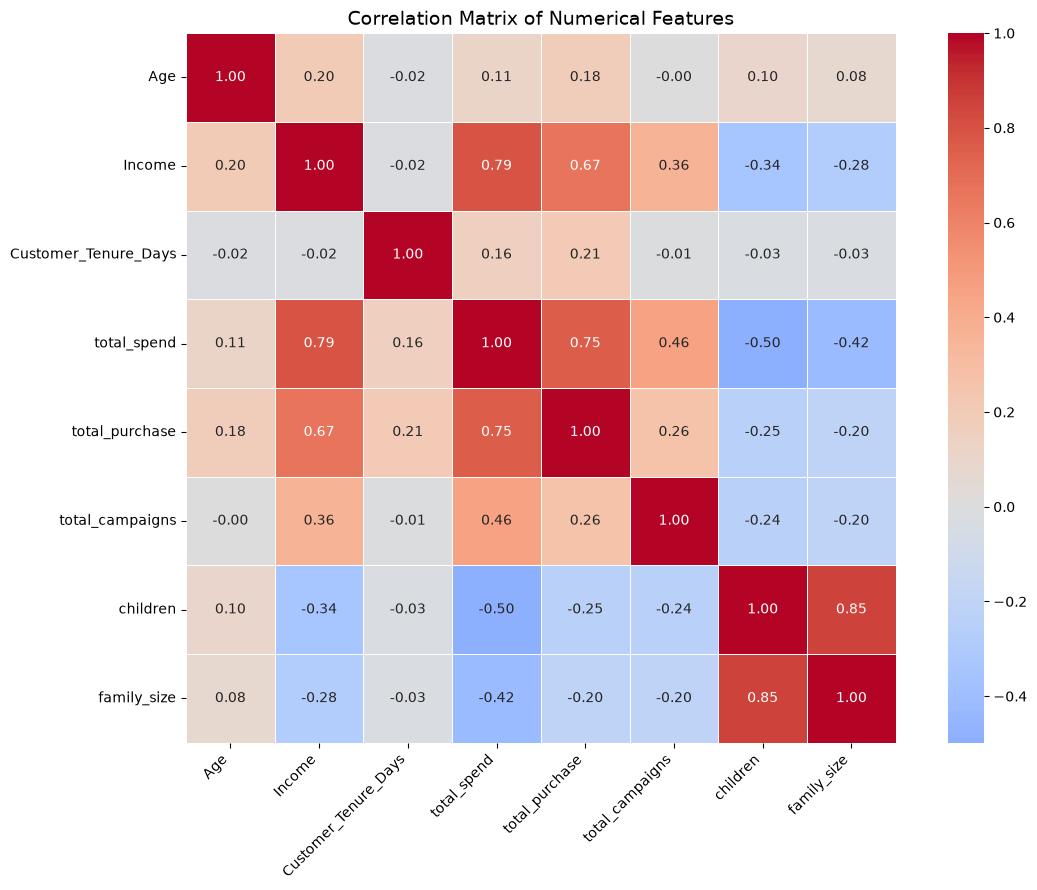

In [159]:
corr_cols = [
    "Age",
    "Income",
    "Customer_Tenure_Days",
    "total_spend",
    "total_purchase",
    "total_campaigns",
    "children",
    "family_size"
]
corr = df[corr_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,linewidths=0.5,square=True)

plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

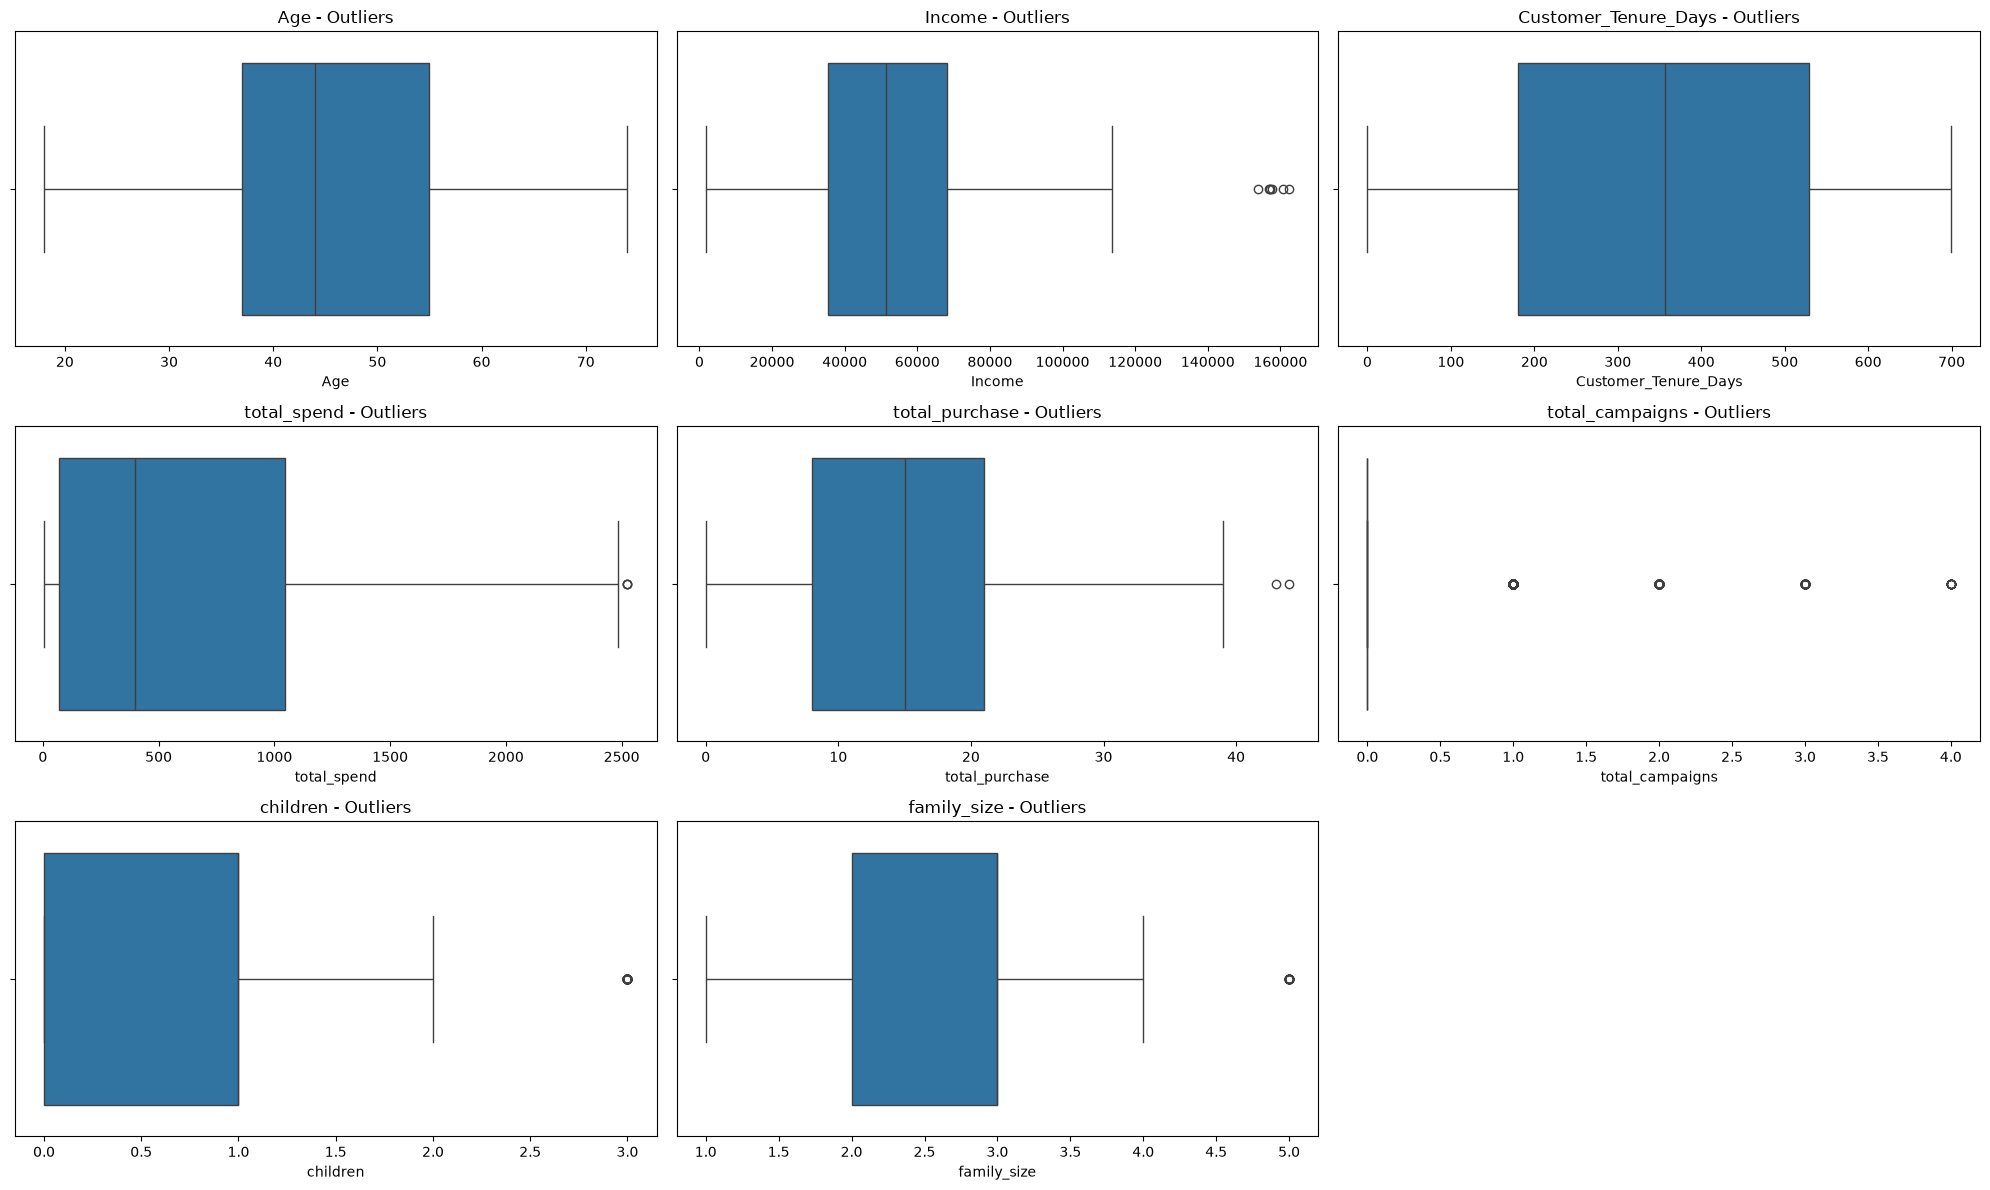

In [160]:
# to analyis outtliers
plt.figure(figsize=(20, 12))
def box_plotting(var, col):
    plt.subplot(3, 3, col)
    sns.boxplot(data=df, x=var)
    plt.title(f"{var} - Outliers")

box_plotting("Age", 1)
box_plotting("Income", 2)
box_plotting("Customer_Tenure_Days", 3)
box_plotting("total_spend", 4)
box_plotting("total_purchase", 5)
box_plotting("total_campaigns", 6)
box_plotting("children", 7)
box_plotting("family_size", 8)

plt.tight_layout()
plt.show()

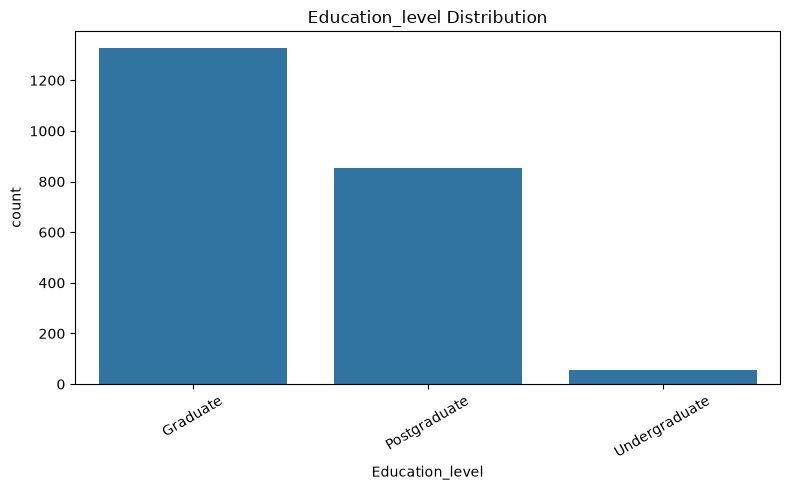

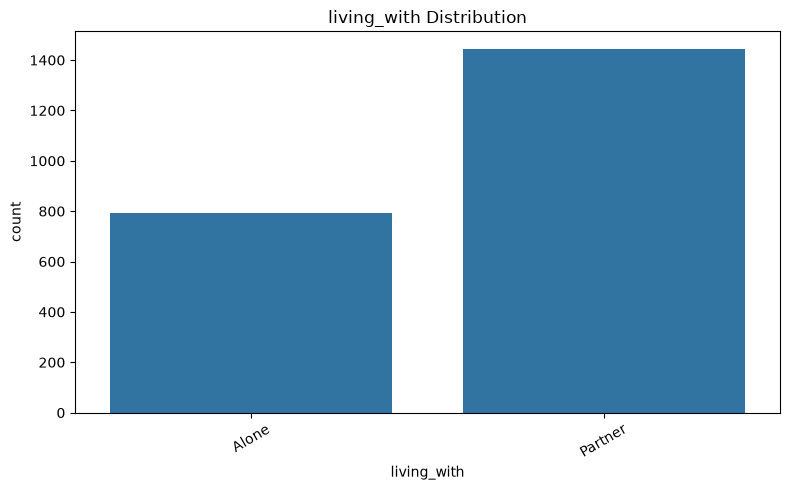

In [161]:
# cat_col showuing
cat_cols = [
    "Education_level",
    "living_with",
]
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df,x=col)
    
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

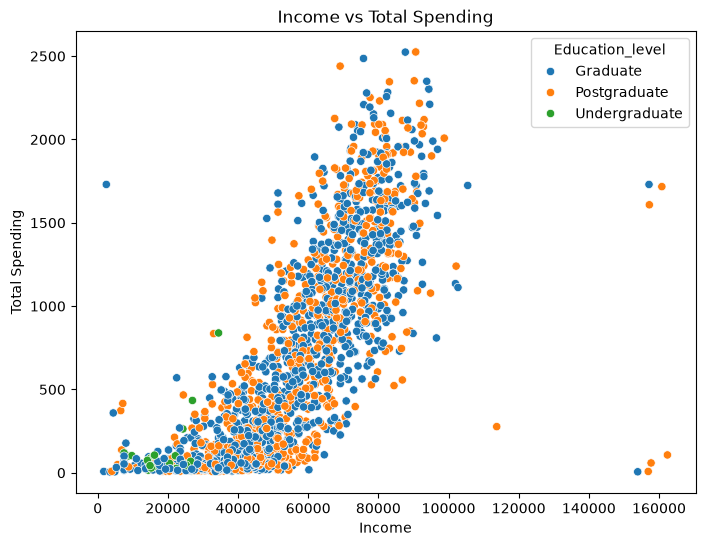

In [162]:
# income vs T.P by Eduction level
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df,x="Income",y="total_spend" , hue ='Education_level' )

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

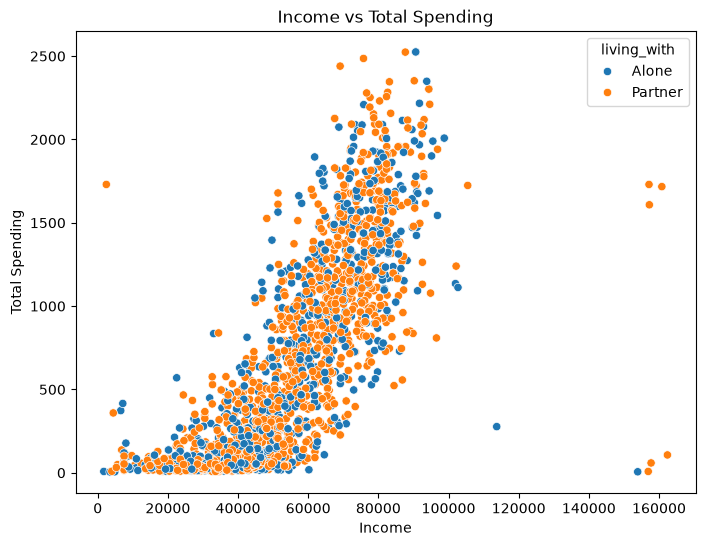

In [163]:
 # income vs Spending by Eduction level
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df,x="Income",y="total_spend" , hue = 'living_with')

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

## Feature Engineering

In [164]:
df.columns.to_list()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Response',
 'Age',
 'Customer_Tenure_Days',
 'total_spend',
 'total_purchase',
 'total_campaigns',
 'children',
 'living_with',
 'family_size',
 'Education_level']

In [165]:
#Droping all all any still working columns
droping_col = [
    'ID',
    'Year_Birth',
    'Education',
    'Marital_Status',
    'Kidhome',
    'Teenhome',
    'Dt_Customer',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'AcceptedCmp1',
    'AcceptedCmp2',
    'Response',
]
df = df.drop(columns= droping_col , errors = 'ignore')

In [166]:
df.columns.to_list()

['Income',
 'Recency',
 'NumWebVisitsMonth',
 'Complain',
 'Age',
 'Customer_Tenure_Days',
 'total_spend',
 'total_purchase',
 'total_campaigns',
 'children',
 'living_with',
 'family_size',
 'Education_level']

In [167]:
# Ending on Cat_col and Assing the x value 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

education_order = [["Undergraduate", "Graduate", "Postgraduate"]]
edu_encoder = OrdinalEncoder(categories=education_order)   # by OHE through ending of cat_col
df["Education_Encoded"] = edu_encoder.fit_transform(df[["Education_level"]])

df["Living_With_Encoded"] = df["living_with"].map({"Alone": 0, "Partner": 1}) # by maping through ending of cat_col

clusting_Features = [
    "Age",
    "Income",
    "Recency",
    "Customer_Tenure_Days",
    "total_spend",
    "total_purchase",
    "total_campaigns",
    "children",
    "family_size",
    "Education_Encoded", 
    "Living_With_Encoded",
    "NumWebVisitsMonth",
    "Complain"
]

X = df[clusting_Features].copy()
print("Feature matrix for clusting " , X.shape)
X.head()

Feature matrix for clusting  (2236, 13)


,Age,Income,Recency,Customer_Tenure_Days,total_spend,total_purchase,total_campaigns,children,family_size,Education_Encoded,Living_With_Encoded,NumWebVisitsMonth,Complain
0,57,58138.0,58,663,1617,25,0,0,1,1.0,0,7,0
1,60,46344.0,38,113,27,6,0,2,3,1.0,0,5,0
2,49,71613.0,26,312,776,21,0,0,2,1.0,1,4,0
3,30,26646.0,26,139,53,8,0,1,3,1.0,1,6,0
4,33,58293.0,94,161,422,19,0,1,3,2.0,1,5,0


## outliers and Skew 

In [168]:
numeric_features = [
    "Age",
    "Income",
    "Recency",
    "Customer_Tenure_Days",
    "total_spend",
    "total_purchase",
    "total_campaigns",
    "children",
    "family_size",
    "NumWebVisitsMonth",
    "Complain"
]

for col in numeric_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((X[col] < lower) | (X[col] > upper)).sum()
    print(
        f"{col} : | "
        f"Outliers={outlier_count}")

Age : | Outliers=0
Income : | Outliers=7
Recency : | Outliers=0
Customer_Tenure_Days : | Outliers=0
total_spend : | Outliers=3
total_purchase : | Outliers=2
total_campaigns : | Outliers=462
children : | Outliers=53
family_size : | Outliers=32
NumWebVisitsMonth : | Outliers=8
Complain : | Outliers=20


In [169]:
#after analysis this data income and total spend and total purchase are tarnforme to "log1p"

In [170]:
#Skewww
skewness = (X[numeric_features].skew().sort_values(ascending=False))
print(skewness)

#after skewness there are income was stable then no get to tarnforme log1p  or why not om complain cuz its object variable only in 0 and 1
#total_spend at 0.86 is moderately right-skewed, so a log transformation 

Complain                10.438160
total_campaigns          2.722452
total_spend              0.860174
children                 0.415519
Income                   0.350773
total_purchase           0.250406
NumWebVisitsMonth        0.207904
Age                      0.092495
family_size              0.086348
Recency                 -0.004299
Customer_Tenure_Days    -0.016397
dtype: float64


In [171]:
#log1p on total_spend
x_model = X.copy()
x_model['total_spend'] = np.log1p(x_model['total_spend'])

print("total_spend skewness before:",X["total_spend"].skew())
print("total_spend skewness after:",x_model["total_spend"].skew())

total_spend skewness before: 0.8601739694705929
total_spend skewness after: -0.3734761578439995


In [172]:
# its come to small left-skewed value then use log_total_spend

## Standard Scaling and Model training

In [212]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
log_features = ["total_spend"]

other_features = [
    "Age",
    "Income",
    "Recency",
    "Customer_Tenure_Days",
    "total_purchase",
    "total_campaigns",
    "children",
    "family_size",
    "Education_Encoded",
    "Living_With_Encoded",
    "NumWebVisitsMonth"
]

In [213]:
preprocessor = ColumnTransformer(
    transformers=[
        ("log_spend",FunctionTransformer(np.log1p),log_features),
        ("other","passthrough",other_features)
    ]
)

In [173]:
#pipeline on SS
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprosssor = Pipeline(steps=[
    ('scaler' , StandardScaler())
])
x_scaler = preprosssor.fit_transform(x_model)

In [174]:
#find K withot pCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score , calinski_harabasz_score , davies_bouldin_score

kmeans_results = []
for k in range(2, 11):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        ))
    ])

    labels = pipeline.fit_predict(x_model)
    X_scaled = pipeline.named_steps["scaler"].transform(x_model)
    
    silhouette = silhouette_score(x_scaler,labels)
    calinski = calinski_harabasz_score(x_scaler,labels)
    davies = davies_bouldin_score(x_scaler,labels)
    inertia = pipeline.named_steps["kmeans"].inertia_
    
    kmeans_results.append({
        "Algorithm": "KMeans",
        "PCA": "No",
        "K": k,
        "Silhouette": silhouette,
        "Calinski_Harabasz": calinski,
        "Davies_Bouldin": davies,
        "Inertia": inertia
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

kmeans_results_df

,Algorithm,PCA,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Inertia
0,KMeans,No,2,0.203394,601.208276,1.825494,22904.106391
1,KMeans,No,3,0.211589,449.997923,1.382952,20717.819998
2,KMeans,No,4,0.157477,414.167851,1.651269,18673.155315
3,KMeans,No,5,0.139040,379.038334,1.784427,17306.783214
4,KMeans,No,6,0.144125,348.987871,1.826887,16307.597370
5,KMeans,No,7,0.147530,333.344087,1.721539,15320.781144
6,KMeans,No,8,0.145010,316.958294,1.760412,14564.370577
7,KMeans,No,9,0.145875,298.792346,1.751460,14019.858470
8,KMeans,No,10,0.149237,283.595307,1.802671,13541.340193


In [175]:
#find K with pCA
from sklearn.decomposition import PCA

pca_results = []
for k in range(2, 11):
    pipeline_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.90)),
        ("kmeans", KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        ))
    ])

    labels = pipeline_pca.fit_predict(x_model)
    x_pca = pipeline_pca[:-1].transform(x_model)

    silhouette = silhouette_score(x_pca , labels)
    calinski = calinski_harabasz_score(x_scaler,labels)
    davies = davies_bouldin_score(x_scaler,labels)
    inertia = pipeline_pca.named_steps["kmeans"].inertia_

    pca_results.append({
        "Algorithm": "KMeans",
        "PCA": "Yes",
        "K": k,
        "Silhouette": silhouette,
        "Calinski_Harabasz": calinski,
        "Davies_Bouldin": davies,
        "Inertia": inertia
    })

pca_results_df = pd.DataFrame(pca_results)
pca_results_df.round(4)

,Algorithm,PCA,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Inertia
0,KMeans,Yes,2,0.2151,601.1577,1.8256,21276.3333
1,KMeans,Yes,3,0.2237,449.9793,1.3830,19090.3949
2,KMeans,Yes,4,0.1668,413.6582,1.6472,17099.6320
3,KMeans,Yes,5,0.1474,378.4923,1.7877,15752.2730
4,KMeans,Yes,6,0.1529,352.6527,1.7720,14660.2682
5,KMeans,Yes,7,0.1530,331.7772,1.7609,13776.4036
6,KMeans,Yes,8,0.1553,315.9810,1.7599,12998.1120
7,KMeans,Yes,9,0.1583,298.1985,1.7497,12465.8305
8,KMeans,Yes,10,0.1617,282.4791,1.7689,12014.9093


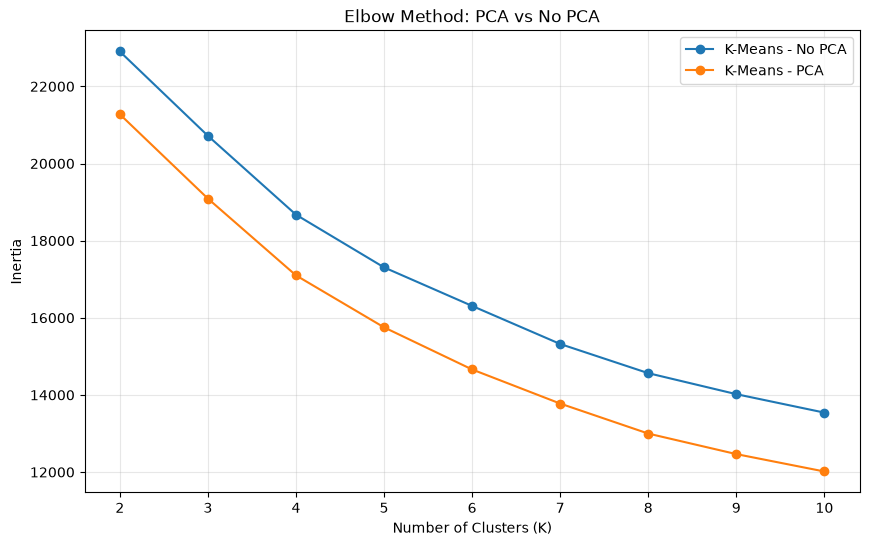

In [176]:
plt.figure(figsize=(10, 6))
plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Inertia"],
    marker="o",
    label="K-Means - No PCA"
)
plt.plot(
    pca_results_df["K"],
    pca_results_df["Inertia"],
    marker="o",
    label="K-Means - PCA"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method: PCA vs No PCA")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

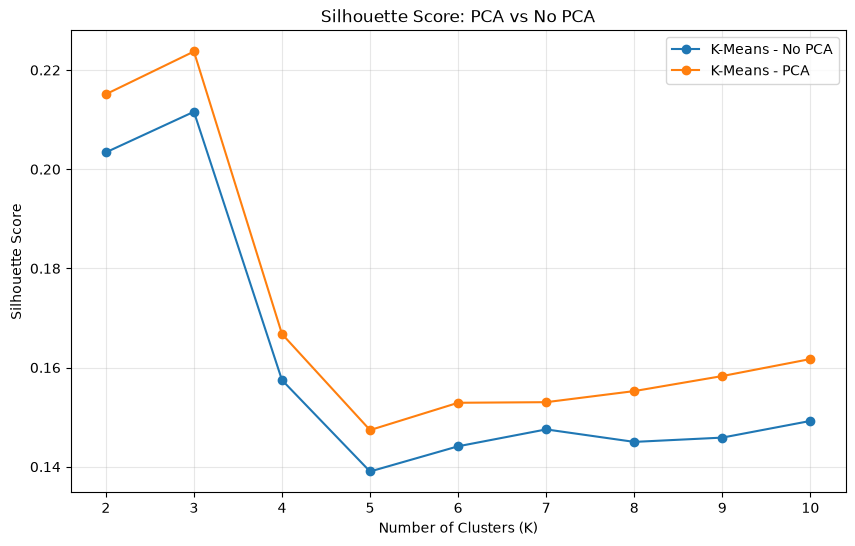

In [177]:
plt.figure(figsize=(10, 6))
plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Silhouette"],
    marker="o",
    label="K-Means - No PCA"
)
plt.plot(
    pca_results_df["K"],
    pca_results_df["Silhouette"],
    marker="o",
    label="K-Means - PCA"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score: PCA vs No PCA")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [178]:
# #K = 3 is currently the strongest candidate for K-Means clustering.
# The PCA-based pipeline provides slightly better cluster separation according to the Silhouette Score.
# However, this is not yet the final model selection.
# Other clustering algorithms such as Agglomerative Clustering and Gaussian Mixture Models should be evaluated before selecting the final production model.

In [179]:
# Another Alorithum to Find better AgglomerativeClustering without pca
from sklearn.cluster import AgglomerativeClustering
agglomerative_results = []
for k in range(2, 11):
    pipeline_agg = Pipeline([
        ("scaler", StandardScaler()),
        ("agglomerative", AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        ))
    ])

    labels = pipeline_agg.fit_predict(x_model)
    x_scaled = pipeline_agg.named_steps["scaler"].transform(x_model)

    silhouette = silhouette_score(x_scaled,labels)
    calinski = calinski_harabasz_score(x_scaled,labels)
    davies = davies_bouldin_score(x_scaled,labels)

    agglomerative_results.append({
        "Algorithm": "Agglomerative",
        "PCA": "No",
        "K": k,
        "Silhouette": silhouette,
        "Calinski_Harabasz": calinski,
        "Davies_Bouldin": davies
    })


agglomerative_results_df = pd.DataFrame(agglomerative_results)
agglomerative_results_df.round(4)

,Algorithm,PCA,K,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,Agglomerative,No,2,0.1771,493.4239,1.9850
1,Agglomerative,No,3,0.1265,392.5587,2.1617
2,Agglomerative,No,4,0.1406,378.6944,1.7234
3,Agglomerative,No,5,0.1275,345.3193,1.7588
4,Agglomerative,No,6,0.1244,313.2286,1.7482
5,Agglomerative,No,7,0.1180,292.8413,1.7727
6,Agglomerative,No,8,0.1207,278.6602,1.8140
7,Agglomerative,No,9,0.1157,258.8849,1.8873
8,Agglomerative,No,10,0.1156,243.4151,1.9333


In [180]:
# agglomerative with pca
agglomerative_pca_results = []
for k in range(2, 11):
    pipeline_agg_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.90)),
        ("agglomerative", AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        ))
    ])

    labels = pipeline_agg_pca.fit_predict(x_model)
    x_pca = pipeline_agg_pca[:-1].transform(x_model)
    
    silhouette = silhouette_score(x_pca,labels)
    calinski = calinski_harabasz_score(x_pca,labels)
    davies = davies_bouldin_score(x_pca,labels)

    agglomerative_pca_results.append({
        "Algorithm": "Agglomerative",
        "PCA": "Yes",
        "K": k,
        "Silhouette": silhouette,
        "Calinski_Harabasz": calinski,
        "Davies_Bouldin": davies
    })


agglomerative_pca_results_df = pd.DataFrame(agglomerative_pca_results)
agglomerative_pca_results_df.round(4)

,Algorithm,PCA,K,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,Agglomerative,Yes,2,0.1856,526.6376,1.9274
1,Agglomerative,Yes,3,0.1919,418.0487,1.4334
2,Agglomerative,Yes,4,0.1390,398.5584,1.6275
3,Agglomerative,Yes,5,0.1208,360.8511,1.8165
4,Agglomerative,Yes,6,0.1309,342.0279,1.8501
5,Agglomerative,Yes,7,0.1271,320.7950,1.7385
6,Agglomerative,Yes,8,0.1299,307.6854,1.7088
7,Agglomerative,Yes,9,0.1321,291.1909,1.7301
8,Agglomerative,Yes,10,0.1331,277.8458,1.7350


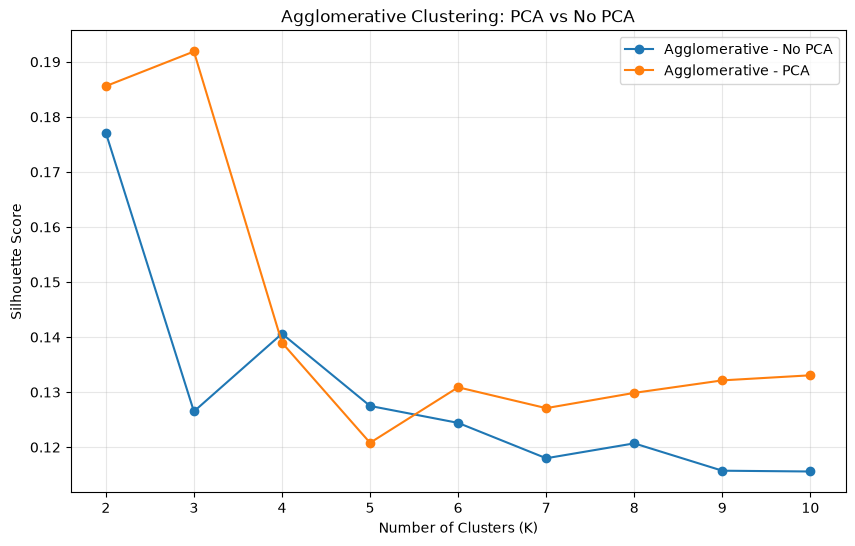

In [181]:
# grapgh 
plt.figure(figsize=(10, 6))

plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Silhouette"],
    marker="o",
    label="Agglomerative - No PCA"
)
plt.plot(
    agglomerative_pca_results_df["K"],
    agglomerative_pca_results_df["Silhouette"],
    marker="o",
    label="Agglomerative - PCA"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Agglomerative Clustering: PCA vs No PCA")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

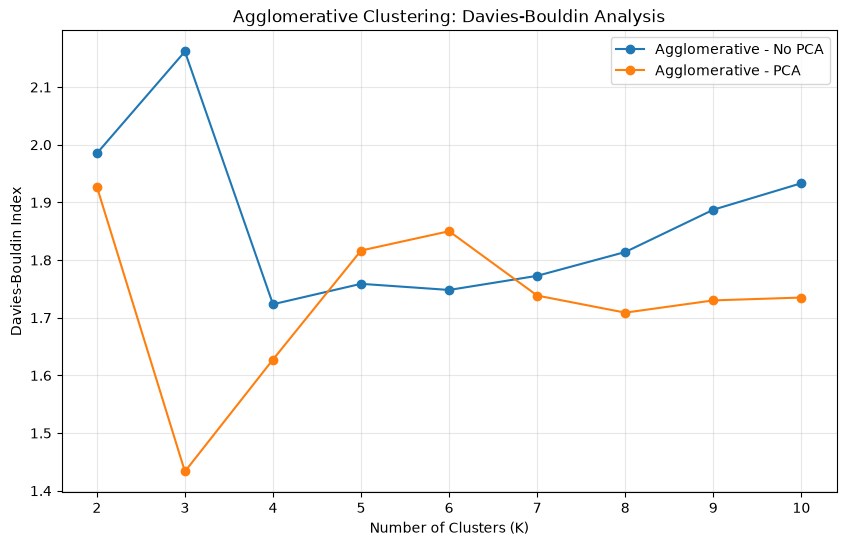

In [182]:
plt.figure(figsize=(10, 6))
plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Davies_Bouldin"],
    marker="o",
    label="Agglomerative - No PCA"
)
plt.plot(
    agglomerative_pca_results_df["K"],
    agglomerative_pca_results_df["Davies_Bouldin"],
    marker="o",
    label="Agglomerative - PCA"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Agglomerative Clustering: Davies-Bouldin Analysis")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

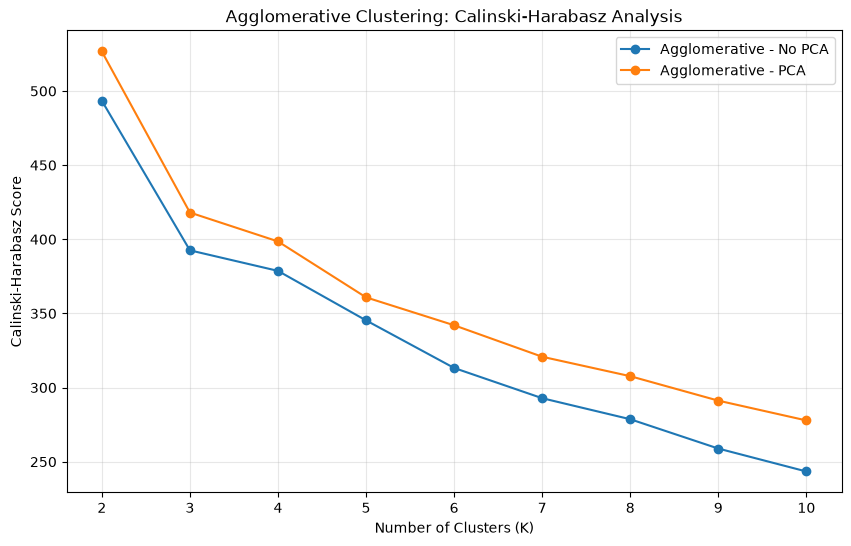

In [183]:
plt.figure(figsize=(10, 6))
plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Calinski_Harabasz"],
    marker="o",
    label="Agglomerative - No PCA"
)
plt.plot(
    agglomerative_pca_results_df["K"],
    agglomerative_pca_results_df["Calinski_Harabasz"],
    marker="o",
    label="Agglomerative - PCA"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Agglomerative Clustering: Calinski-Harabasz Analysis")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [184]:
# Agglomerative Clustering showed better results with PCA than without PCA. K=3 was the strongest configuration, with a Silhouette Score of 0.1919. 
# However,it performed below PCA + K-Means (0.2237), 
# so K-Means + PCA remains the current leading model.

In [185]:
# Anther Alorithum GaussianMixture withour pca
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

gmm_results = []
for k in range(2, 11):
    pipeline_gmm = Pipeline([
        ("scaler", StandardScaler()),
        ("gmm", GaussianMixture(
            n_components=k,
            random_state=42,
            n_init=10
        ))
    ])

    labels = pipeline_gmm.fit_predict(x_model)
    x_scaled = pipeline_gmm.named_steps["scaler"].transform(x_model)
    silhouette = silhouette_score(x_scaled,labels)
    calinski = calinski_harabasz_score(x_scaled,labels)
    davies = davies_bouldin_score(x_scaled,labels)

    gmm_results.append({
        "Algorithm": "GMM",
        "PCA": "No",
        "K": k,
        "Silhouette": silhouette,
        "Calinski_Harabasz": calinski,
        "Davies_Bouldin": davies
    })

gmm_results_df = pd.DataFrame(gmm_results)
gmm_results_df.round(4)

,Algorithm,PCA,K,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,GMM,No,2,0.5966,187.7204,0.6233
1,GMM,No,3,0.1326,241.7998,1.9607
2,GMM,No,4,0.1229,225.9650,1.9636
3,GMM,No,5,0.1200,173.7495,1.9948
4,GMM,No,6,0.1032,217.2864,2.0033
5,GMM,No,7,0.0839,165.0995,2.4358
6,GMM,No,8,0.0498,128.2625,2.4290
7,GMM,No,9,0.0764,129.0078,2.3942
8,GMM,No,10,0.0701,149.3045,2.7327


In [186]:
# Anther Alorithum GaussianMixture with pca
gmm_pca_results = []
for k in range(2, 11):
    pipeline_gmm_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.90)),
        ("gmm", GaussianMixture(
            n_components=k,
            random_state=42,
            n_init=10
        ))
    ])

    labels = pipeline_gmm_pca.fit_predict(x_model)
    x_pca = pipeline_gmm_pca[:-1].transform(x_model)
    
    silhouette = silhouette_score(x_pca,labels)
    calinski = calinski_harabasz_score(x_pca,labels)
    davies = davies_bouldin_score(x_pca,labels)

    gmm_pca_results.append({
        "Algorithm": "GMM",
        "PCA": "Yes",
        "K": k,
        "Silhouette": silhouette,
        "Calinski_Harabasz": calinski,
        "Davies_Bouldin": davies
    })

gmm_pca_results_df = pd.DataFrame(
    gmm_pca_results
)

gmm_pca_results_df.round(4)

,Algorithm,PCA,K,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,GMM,Yes,2,0.5232,127.1001,1.3664
1,GMM,Yes,3,0.1400,187.8694,2.0666
2,GMM,Yes,4,0.1407,217.8617,1.9410
3,GMM,Yes,5,0.1003,177.2688,2.4261
4,GMM,Yes,6,0.0963,179.0621,2.5847
5,GMM,Yes,7,0.0750,150.0444,2.5176
6,GMM,Yes,8,0.0570,125.2637,2.6656
7,GMM,Yes,9,0.0766,150.2024,2.8726
8,GMM,Yes,10,0.1009,166.6838,2.8332


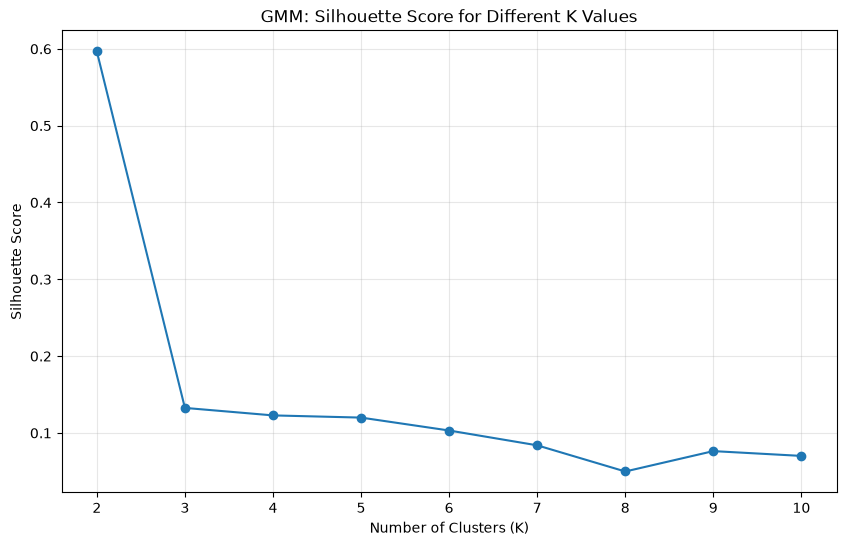

In [187]:
#Silhouette Score vs K    
plt.figure(figsize=(10, 6))
plt.plot(
    gmm_results_df["K"],
    gmm_results_df["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("GMM: Silhouette Score for Different K Values")
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.show()

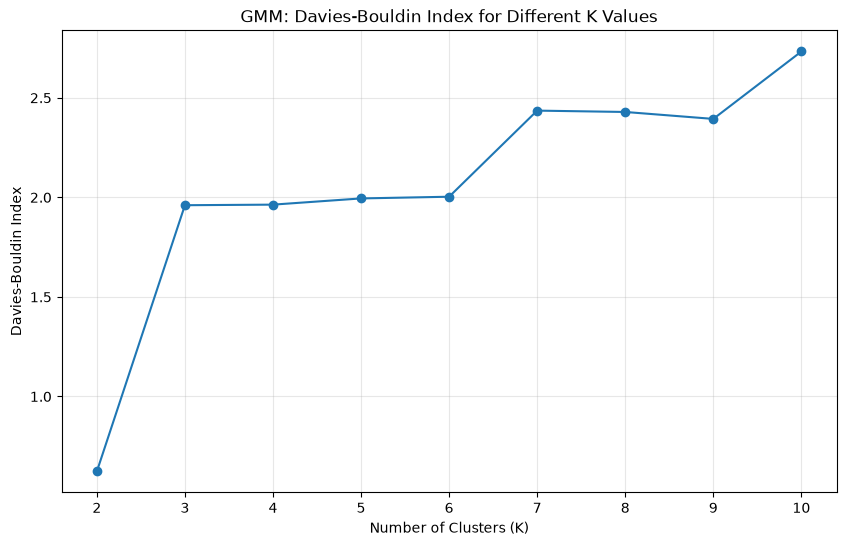

In [188]:
#Davies-Bouldin graph
plt.figure(figsize=(10, 6))
plt.plot(
    gmm_results_df["K"],
    gmm_results_df["Davies_Bouldin"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("GMM: Davies-Bouldin Index for Different K Values")
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)

plt.show()

In [189]:
# #The graph shows the variation in Silhouette Score as the number of clusters increases. 
# The K value is 3 corresponding to the highest Silhouette Score represents the strongest candidate because it provides better cluster separation and cohesion.

In [190]:
 # after analyis i will choose pca + kmean = 3 buc when i choose Gmm k =2 there are show very diffeent for two custing

In [191]:
for k in [2, 3]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.90, random_state=42)),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=20))
    ])
    labels = pipe.fit_predict(x_model)
    x_pca = pipe[:-1].transform(x_model)
    print(f"K={k} | Silhouette={silhouette_score(x_pca, labels):.4f} | "
          f"Calinski={calinski_harabasz_score(x_pca, labels):.1f} | "
          f"Davies={davies_bouldin_score(x_pca, labels):.4f}")

K=2 | Silhouette=0.2151 | Calinski=646.8 | Davies=1.7546
K=3 | Silhouette=0.2237 | Calinski=488.1 | Davies=1.3290


In [205]:
clusting_Features = [
    "Age",
    "Income",
    "Recency",
    "Customer_Tenure_Days",
    "total_spend",
    "total_purchase",
    "total_campaigns",
    "children",
    "family_size",
    "Education_Encoded",
    "Living_With_Encoded",
    "NumWebVisitsMonth"
]

In [206]:
X = df[clusting_Features].copy()
print("Features used by final model:")
print(X.columns.tolist())
print("Shape:", X.shape)

Features used by final model:
['Age', 'Income', 'Recency', 'Customer_Tenure_Days', 'total_spend', 'total_purchase', 'total_campaigns', 'children', 'family_size', 'Education_Encoded', 'Living_With_Encoded', 'NumWebVisitsMonth']
Shape: (2236, 12)


In [214]:
FINAL_K = 2

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("kmeans", KMeans(
        n_clusters=FINAL_K,
        random_state=42,
        n_init=20
    ))
])

df["Cluster"] = final_pipeline.fit_predict(X)
x_pca_final = final_pipeline[:-1].transform(X)
print("Final Silhouette:", silhouette_score(x_pca_final, df["Cluster"]))

print("\nCluster sizes:")
print(df["Cluster"].value_counts())

Final Silhouette: 0.22073904706124597

Cluster sizes:
Cluster
1    1165
0    1071
Name: count, dtype: int64


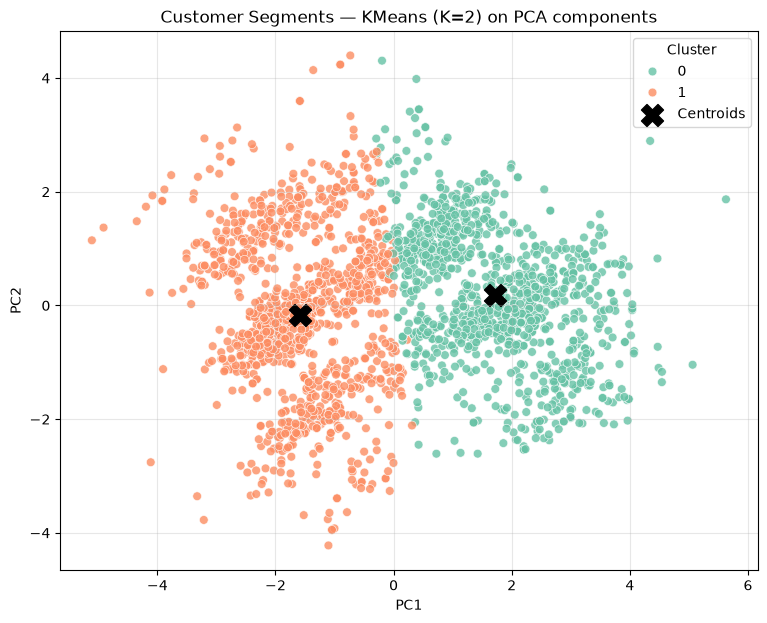

In [215]:
#graph of cnertoid
plt.figure(figsize=(9, 7))

sns.scatterplot(x=x_pca_final[:, 0], y=x_pca_final[:, 1],hue=df["Cluster"], palette="Set2", s=40, edgecolor="white", alpha=0.8)
centroids = final_pipeline.named_steps["kmeans"].cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],c="black", marker="X", s=250, label="Centroids")

plt.title(f"Customer Segments — KMeans (K={FINAL_K}) on PCA components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [216]:
# business insight
cluster_profile = df.groupby("Cluster")[clusting_Features].mean().round(1)
cluster_profile["count"] = df["Cluster"].value_counts()
cluster_profile

,Age,Income,Recency,Customer_Tenure_Days,total_spend,total_purchase,total_campaigns,children,family_size,Education_Encoded,Living_With_Encoded,NumWebVisitsMonth,count
Cluster,,,,,,,,,,,,,
0,47.5,69067.4,49.0,373.4,1111.6,20.9,0.5,0.6,2.2,1.4,0.6,3.9,1071
1,42.9,36218.8,49.2,335.7,141.1,9.3,0.1,1.3,3.0,1.3,0.7,6.6,1165


In [217]:
#Business Recommendations
business_recommendations = pd.DataFrame({
    "Cluster": [0, 1],
    "Segment": ["Low-Value / Browsing Customers","High-Value Customers"],
    "Recommendation": [
        "Use targeted discounts, product recommendations, bundles, and conversion campaigns.",
        "Use loyalty rewards, premium offers, personalized recommendations, retention, and cross-selling."
    ]
})

business_recommendations

,Cluster,Segment,Recommendation
0,0,Low-Value / Browsing Customers,"Use targeted discounts, product recommendation..."
1,1,High-Value Customers,"Use loyalty rewards, premium offers, personali..."


## Save The Model


In [218]:
import joblib
joblib.dump(final_pipeline,"customer_segmentation_pipe.pkl")
print("Pipeline saved successfully.")

Pipeline saved successfully.
